# Task 2: Predict Future Stock Prices


# Objective:
Use historical stock data to predict the next day's closing price.

In [19]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

#LOAD DATA

In [20]:
df = yf.download("AAPL", start="2020-01-01", end="2025-01-01") #loading stock data of apple
print(df.head())

/tmp/ipykernel_6304/3200423577.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2025-01-01") #loading stock data of apple
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400520  72.460784  71.156682  71.409785  135480400
2020-01-03  71.696625  72.455943  71.472447  71.629130  146322800
2020-01-06  72.267921  72.306491  70.568495  70.819193  118387200
2020-01-07  71.928062  72.533103  71.708703  72.277586  108872000
2020-01-08  73.085106  73.386423  71.631552  71.631552  132079200


# DATA PREPROCESSING

In [21]:
df = df[['Open', 'High', 'Low', 'Volume', 'Close']] #selecting features for predictions

In [22]:
df['Target'] = df['Close'].shift(-1) #shifts the close column by one row

In [23]:
df.dropna(inplace=True) #if last row becomes empty remove it

In [24]:
df.head()

Price,Open,High,Low,Volume,Close,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,71.409785,72.460784,71.156682,135480400,72.400520,71.696625
2020-01-03,71.629130,72.455943,71.472447,146322800,71.696625,72.267921
2020-01-06,70.819193,72.306491,70.568495,118387200,72.267921,71.928062
2020-01-07,72.277586,72.533103,71.708703,108872000,71.928062,73.085106
2020-01-08,71.631552,73.386423,71.631552,132079200,73.085106,74.637489


# FEATURES AND TARGET

In [25]:
x = df[['Open', 'High', 'Low', 'Volume']] # x is features
y = df['Target'] # y is target

# TRAIN TEST SPLIT

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

# MODEL TRAINING

LINEAR REGRESSION

In [27]:
lr=LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
mse_lr = mean_squared_error(y_test, y_pred_lr) #MSE measures how wrong predictions are

RANDOM FOREST

In [28]:
rf=RandomForestRegressor()
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)

# MODEL EVALUATION

In [29]:
#we are evaluating model on the basis of MSE and smaller the val better the model
print("MSE for Linear Regression: ", mse_lr)
print("MSE for Random Forest: ", mse_rf)

MSE for Linear Regression:  9.620178150937976
MSE for Random Forest:  676.4869875398224


# VISUALIZATION

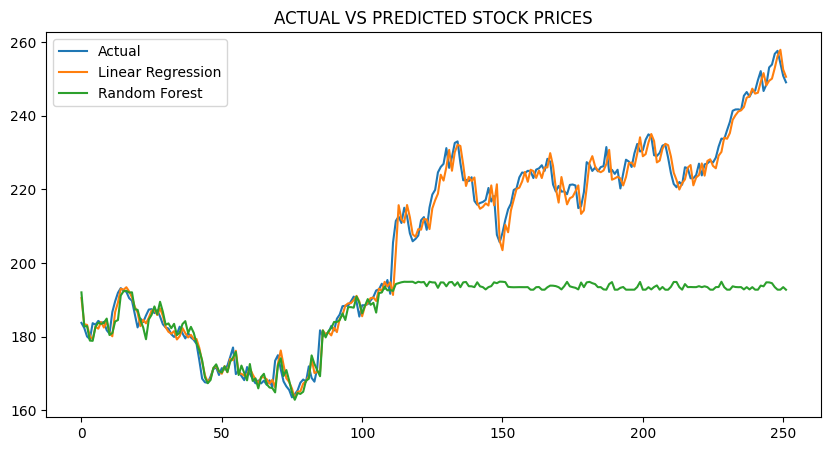

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_lr, label='Linear Regression')
plt.plot(y_pred_rf, label='Random Forest')
plt.legend()
plt.title("ACTUAL VS PREDICTED STOCK PRICES")
plt.show()

# FINAL INSIGHTS

In this we learn that both the models were able to predict the stock prices but Linear Regression performed better than Random Forest because it produced a lower Mean Squared Error (MSE).